# 03 — From Cramer to Computation: Bernoulli Importance Sampling

> **Project:** `large-deviations`  
> **Theme:** rare-event Monte Carlo, exponential tilting, likelihood ratios, variance reduction  
> **Distribution:** Bernoulli / Binomial  
> **Quant finance interpretation:** independent default portfolio tail risk  

This notebook is **not** another verification of Cramer's theorem.

Notebook 02 answered:

```text
What is the true exponential decay rate of the Bernoulli tail?
```

This notebook answers a different question:

```text
How do we estimate that tiny tail probability efficiently by simulation?
```

The target probability is

$$
p_n =
\mathbb P\left(\frac{S_n}{n}\ge q\right),
\qquad
S_n=X_1+\cdots+X_n,
\qquad
X_i\sim \mathrm{Bernoulli}(p).
$$

In credit-risk language, $X_i$ is a default indicator, $S_n/n$ is the realized default
rate, and $\{S_n/n\ge q\}$ is a large-loss event.

The quant message is:

```text
Naive Monte Carlo waits for rare defaults to happen.
Importance sampling changes the simulation law so the rare loss becomes typical.
The likelihood ratio keeps the estimator unbiased.
```


## Position in the project

Notebook 02 produced the exact binomial benchmark and checked the Cramer logarithmic
scale.

Here we use that benchmark only as **ground truth**. The new object is the estimator.

Under exponential tilting,

$$
\frac{dP_\theta}{dP}
=
\exp(\theta S_n-n\Gamma(\theta)),
$$

so the inverse likelihood ratio is

$$
\frac{dP}{dP_\theta}
=
\exp(-\theta S_n+n\Gamma(\theta)).
$$

Therefore,

$$
p_n
=
\mathbb E_\theta
\left[
1_{\{S_n/n\ge q\}}
\exp(-\theta S_n+n\Gamma(\theta))
\right].
$$

The saddle-point tilt solves

$$
\Gamma'(\theta_q)=q.
$$

For Bernoulli variables, this means that under the tilted law,

$$
X_i\sim \mathrm{Bernoulli}(q),
$$

so the formerly rare default-rate event is moved near the center of the simulation law.


## 1. Imports and project setup

The notebook is designed to run from either:

- the repository root,
- the `notebooks/` directory,
- or an installed environment.

In [21]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from IPython.display import display

# Make the project package importable from the repository root or from notebooks/.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]

for root in candidate_roots:
    src_path = root / "src"
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

from large_deviations import bernoulli_ld
from large_deviations.importance_sampling import (
    bernoulli_tail_naive_mc,
    bernoulli_tail_tilted_mc,
    binomial_tail_threshold,
)
from large_deviations.importance_sampling.core import log_likelihood_ratio_sum
from large_deviations.tilting import theta_for_tilted_mean


plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": True,
    }
)

BASE_SEED = 20260506

## 2. Helper functions

We keep exact binomial probabilities in log form whenever possible. This avoids underflow
and gives a clean benchmark for the Monte Carlo estimates.

In [ ]:
def exact_binomial_tail_log_probability(n: int, p: float, q: float) -> tuple[int, float]:
    """Return k and log P[Binomial(n, p) >= k], where k = ceil(n q)."""
    k = binomial_tail_threshold(n=n, q=q)
    log_tail = float(binom.logsf(k - 1, n, p))
    return k, log_tail


def safe_exp(log_value: float) -> float:
    """Exponentiate a log-probability while avoiding underflow."""
    if log_value < -745:
        return 0.0
    return float(np.exp(log_value))


def display_table(df: pd.DataFrame, precision: int = 4) -> None:
    """Display a readable numeric table."""
    display(
        df.style.format(
            precision=precision,
            na_rep="—",
        )
    )

## 3. Tail-risk parameters

We use the same independent-default setup as in notebook 02:

$$
p=2\%,
\qquad
q=10\%.
$$

Interpretation:

> The true marginal default probability is $2\%$, but we estimate the probability that the realized default rate exceeds $10\%$.

In [23]:
p = 0.02
q = 0.10

dist = bernoulli_ld(p)

theta_q = theta_for_tilted_mean(dist, target_mean=q)
gamma_theta_q = dist.cgf(theta_q)
tilted_p = float(dist.tilted_parameter(theta_q))
rate_q = dist.rate_function(q)

parameter_summary = pd.DataFrame(
    {
        "quantity": [
            "original Bernoulli probability p",
            "tail threshold q",
            "saddle-point theta_q",
            "Gamma(theta_q)",
            "tilted Bernoulli probability p_theta",
            "Gamma*(q)",
        ],
        "value": [
            p,
            q,
            theta_q,
            gamma_theta_q,
            tilted_p,
            rate_q,
        ],
    }
)

display_table(parameter_summary, precision=6)

,quantity,value
0,original Bernoulli probability p,0.020000
1,tail threshold q,0.100000
2,saddle-point theta_q,1.694596
3,Gamma(theta_q),0.085158
4,tilted Bernoulli probability p_theta,0.100000
5,Gamma*(q),0.084302


The key fact is visible in the table:

$$
p_\theta=q.
$$

So under the tilted measure, the event $S_n/n\ge q$ is no longer deep in the tail.

## 4. Exact benchmark for simulation

We need exact binomial probabilities for one reason only:

```text
to know whether the Monte Carlo estimators are accurate.
```

We will not redo the Cramer convergence study from notebook 02. Instead, we compute:

- the exact tail probability,
- the expected number of naive Monte Carlo hits for a fixed simulation budget,
- the number of paths needed to see roughly one or ten naive hits.

This makes the rare-event simulation problem visible.


In [24]:
sample_size = 100_000
mc_n_values = np.array([50, 100, 200, 500, 1_000, 2_000], dtype=int)

benchmark_rows = []

for n in map(int, mc_n_values):
    k, log_exact = exact_binomial_tail_log_probability(n=n, p=p, q=q)
    exact_probability = safe_exp(log_exact)

    benchmark_rows.append(
        {
            "n": n,
            "threshold_k": k,
            "exact_log_probability": log_exact,
            "exact_probability": exact_probability,
            "expected_naive_hits_with_N": sample_size * exact_probability,
            "naive_paths_for_1_expected_hit": 1.0 / exact_probability,
            "naive_paths_for_10_expected_hits": 10.0 / exact_probability,
        }
    )

benchmark_table = pd.DataFrame(benchmark_rows)

display(
    benchmark_table.style.format(
        {
            "exact_log_probability": "{:.3f}",
            "exact_probability": "{:.3e}",
            "expected_naive_hits_with_N": "{:.3e}",
            "naive_paths_for_1_expected_hit": "{:.3e}",
            "naive_paths_for_10_expected_hits": "{:.3e}",
        }
    )
)


,n,threshold_k,exact_log_probability,exact_probability,expected_naive_hits_with_N,naive_paths_for_1_expected_hit,naive_paths_for_10_expected_hits
0,50,5,-5.742,3.210e-03,3.210e+02,3.116e+02,3.116e+03
1,100,10,-10.277,3.442e-05,3.442e+00,2.906e+04,2.906e+05
2,200,20,-19.039,5.391e-09,5.391e-04,1.855e+08,1.855e+09
3,500,50,-44.777,3.577e-20,3.577e-15,2.796e+19,2.796e+20
4,1000,100,-87.271,1.255e-38,1.255e-33,7.969e+37,7.969e+38
5,2000,200,-171.918,2.173e-75,2.173e-70,4.602e+74,4.602e+75


The last columns are the Monte Carlo warning signal.

If the exact probability is much smaller than $1/N$, a naive simulation with $N$
paths will usually produce zero hits. That is not a theory problem; it is an engineering
problem.

This is the first practical lesson: a rare-event probability can be perfectly well-defined mathematically, yet invisible to a finite Monte Carlo budget.


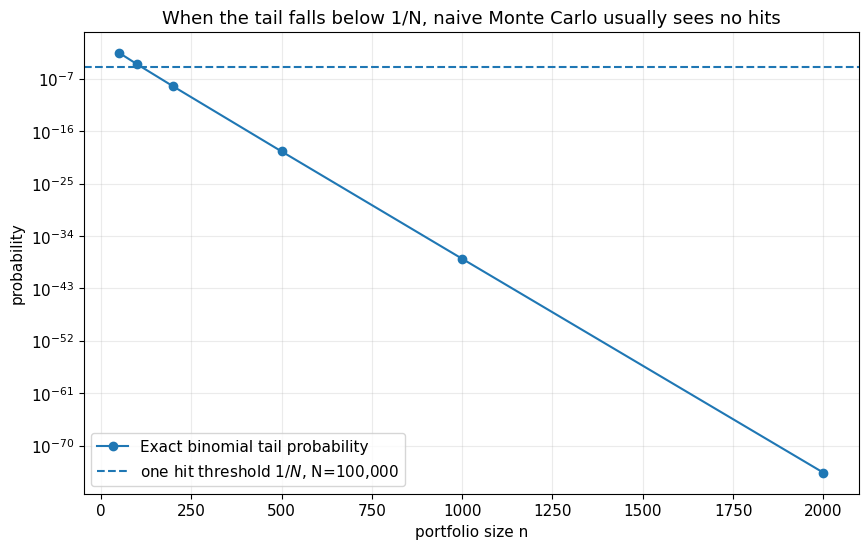

In [25]:
plt.figure()
plt.semilogy(
    benchmark_table["n"],
    benchmark_table["exact_probability"],
    marker="o",
    label="Exact binomial tail probability",
)
plt.axhline(
    1.0 / sample_size,
    linestyle="--",
    label=rf"one hit threshold $1/N$, N={sample_size:,}",
)
plt.xlabel("portfolio size n")
plt.ylabel("probability")
plt.title("When the tail falls below 1/N, naive Monte Carlo usually sees no hits")
plt.legend()
plt.show()


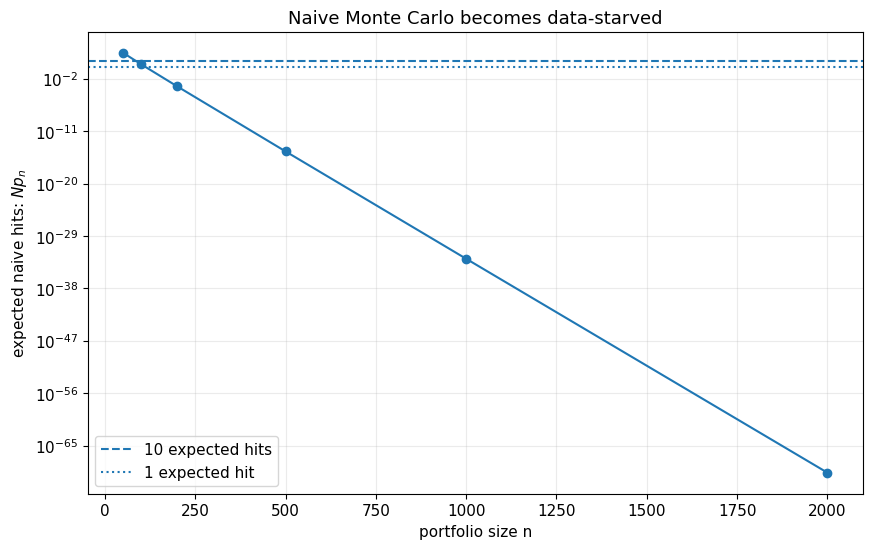

In [26]:
plt.figure()
plt.semilogy(
    benchmark_table["n"],
    benchmark_table["expected_naive_hits_with_N"],
    marker="o",
)
plt.axhline(10.0, linestyle="--", label="10 expected hits")
plt.axhline(1.0, linestyle=":", label="1 expected hit")
plt.xlabel("portfolio size n")
plt.ylabel(r"expected naive hits: $N p_n$")
plt.title("Naive Monte Carlo becomes data-starved")
plt.legend()
plt.show()


## 5. Why the tilted law helps

The naive law has mean $np$. The tilted law has mean $nq$.

For $n=100$:

$$
np=2,
\qquad
nq=10.
$$

The event $S_n\ge 10$ is a far-right tail event under the original law, but it sits around the center of the tilted law.

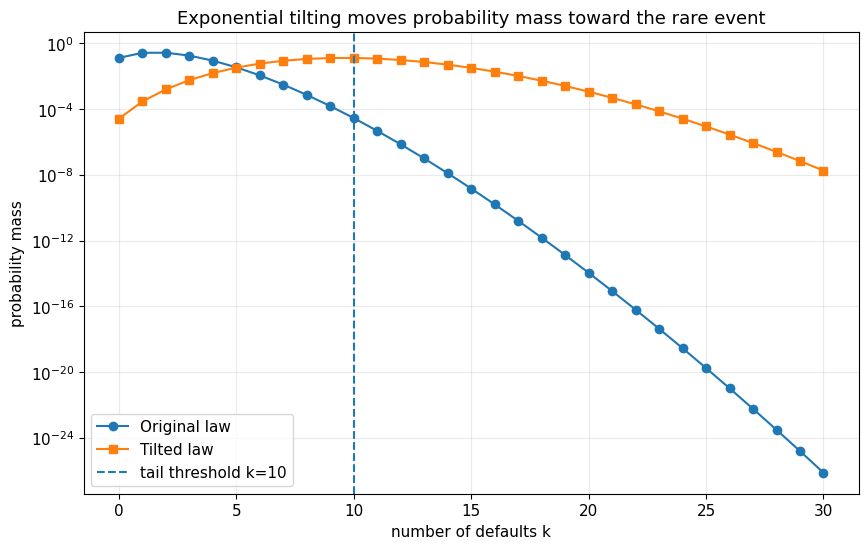

In [27]:
n_demo = 100
k_demo = binomial_tail_threshold(n=n_demo, q=q)
x_values = np.arange(0, 31)

original_pmf = binom.pmf(x_values, n_demo, p)
tilted_pmf = binom.pmf(x_values, n_demo, tilted_p)

pmf_table = pd.DataFrame(
    {
        "k": x_values,
        "original_pmf_Bin(n,p)": original_pmf,
        "tilted_pmf_Bin(n,p_theta)": tilted_pmf,
    }
)

plt.figure()
plt.semilogy(pmf_table["k"], pmf_table["original_pmf_Bin(n,p)"], marker="o", label="Original law")
plt.semilogy(pmf_table["k"], pmf_table["tilted_pmf_Bin(n,p_theta)"], marker="s", label="Tilted law")
plt.axvline(k_demo, linestyle="--", label=f"tail threshold k={k_demo}")
plt.xlabel("number of defaults k")
plt.ylabel("probability mass")
plt.title("Exponential tilting moves probability mass toward the rare event")
plt.legend()
plt.show()

Under the tilted law, we do **not** change the target probability.

We only change the simulation law, then correct the bias with

$$
\exp(-\theta S_n+n\Gamma(\theta)).
$$

The tilted law is only the simulation law. The likelihood ratio then maps each simulated path back to the original probability measure.

## 6. Monte Carlo experiment

We now compare:

```text
naive Monte Carlo
vs
exponential-tilting importance sampling
```

For each $n$, both estimators use the same number of simulated paths.

The naive estimator is expected to return zero once the event probability is much smaller than $1/N$.

In [28]:
mc_rows = []

for n in map(int, mc_n_values):
    k, log_exact = exact_binomial_tail_log_probability(n=n, p=p, q=q)
    exact_probability = safe_exp(log_exact)

    naive_rng = np.random.default_rng(BASE_SEED + int(n))
    tilted_rng = np.random.default_rng(BASE_SEED + 10_000 + int(n))

    naive_estimate = bernoulli_tail_naive_mc(
        n=n,
        p=p,
        q=q,
        sample_size=sample_size,
        rng=naive_rng,
    )

    tilted_estimate = bernoulli_tail_tilted_mc(
        n=n,
        p=p,
        q=q,
        sample_size=sample_size,
        rng=tilted_rng,
    )

    naive_hits = int(round(naive_estimate.estimate * sample_size))
    tilted_event_probability = float(binom.sf(k - 1, n, tilted_p))

    theoretical_naive_standard_error = math.sqrt(
        exact_probability * (1.0 - exact_probability) / sample_size
    )
    theoretical_naive_relative_error = (
        theoretical_naive_standard_error / exact_probability
        if exact_probability > 0.0
        else np.inf
    )

    variance_reduction_vs_naive = (
        (theoretical_naive_standard_error / tilted_estimate.standard_error) ** 2
        if tilted_estimate.standard_error > 0.0
        else np.inf
    )

    mc_rows.append(
        {
            "n": n,
            "threshold_k": k,
            "exact_probability": exact_probability,
            "expected_naive_hits": sample_size * exact_probability,
            "observed_naive_hits": naive_hits,
            "naive_estimate": naive_estimate.estimate,
            "naive_relative_error_observed": naive_estimate.relative_error,
            "naive_relative_error_theoretical": theoretical_naive_relative_error,
            "tilted_event_probability": tilted_event_probability,
            "tilted_estimate": tilted_estimate.estimate,
            "tilted_standard_error": tilted_estimate.standard_error,
            "tilted_relative_error": tilted_estimate.relative_error,
            "variance_reduction_vs_naive": variance_reduction_vs_naive,
        }
    )

mc_table = pd.DataFrame(mc_rows)

display(
    mc_table.style.format(
        {
            "exact_probability": "{:.3e}",
            "expected_naive_hits": "{:.3e}",
            "naive_estimate": "{:.3e}",
            "naive_relative_error_observed": "{:.3e}",
            "naive_relative_error_theoretical": "{:.3e}",
            "tilted_event_probability": "{:.3f}",
            "tilted_estimate": "{:.3e}",
            "tilted_standard_error": "{:.3e}",
            "tilted_relative_error": "{:.3%}",
            "variance_reduction_vs_naive": "{:.3e}",
        }
    )
)


,n,threshold_k,exact_probability,expected_naive_hits,observed_naive_hits,naive_estimate,naive_relative_error_observed,naive_relative_error_theoretical,tilted_event_probability,tilted_estimate,tilted_standard_error,tilted_relative_error,variance_reduction_vs_naive
0,50,5,3.210e-03,3.210e+02,357,3.570e-03,5.283e-02,5.573e-02,0.569,3.204e-03,1.763e-05,0.550%,1.029e+02
1,100,10,3.442e-05,3.442e+00,2,2.000e-05,7.071e-01,5.390e-01,0.549,3.446e-05,2.299e-07,0.667%,6.513e+03
2,200,20,5.391e-09,5.391e-04,0,0.000e+00,inf,4.307e+01,0.534,5.429e-09,4.376e-11,0.806%,2.815e+07
3,500,50,3.577e-20,3.577e-15,0,0.000e+00,inf,1.672e+07,0.522,3.538e-20,3.680e-22,1.040%,2.641e+18
4,1000,100,1.255e-38,1.255e-33,0,0.000e+00,inf,2.823e+16,0.515,1.243e-38,1.550e-40,1.247%,5.220e+36
5,2000,200,2.173e-75,2.173e-70,0,0.000e+00,inf,6.784e+34,0.511,2.222e-75,3.278e-77,1.475%,2.023e+73


Interpretation:

- `expected_naive_hits` is $N p_n$.
- If this number is close to zero, the naive estimator is very likely to return zero.
- `tilted_event_probability` is the probability of the event under the tilted simulation law.
- The tilted event probability is not tiny: the event is now regularly observed.

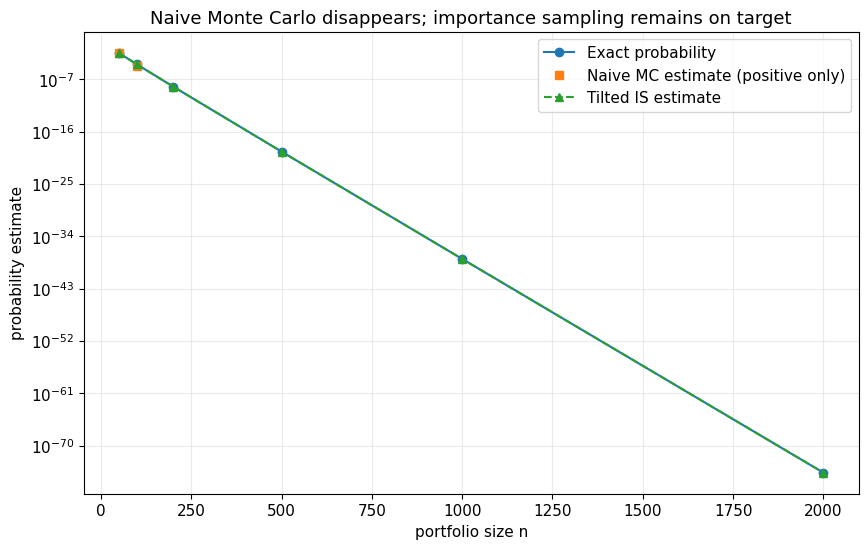

In [29]:
plt.figure()
plt.semilogy(
    mc_table["n"],
    mc_table["exact_probability"],
    marker="o",
    label="Exact probability",
)

positive_naive = mc_table["naive_estimate"] > 0
plt.semilogy(
    mc_table.loc[positive_naive, "n"],
    mc_table.loc[positive_naive, "naive_estimate"],
    marker="s",
    linestyle="",
    label="Naive MC estimate (positive only)",
)

plt.semilogy(
    mc_table["n"],
    mc_table["tilted_estimate"],
    marker="^",
    linestyle="--",
    label="Tilted IS estimate",
)

plt.xlabel("portfolio size n")
plt.ylabel("probability estimate")
plt.title("Naive Monte Carlo disappears; importance sampling remains on target")
plt.legend()
plt.show()

Zero naive estimates are not plotted on the log-scale. Their absence is the point: the naive estimator has run out of tail observations.

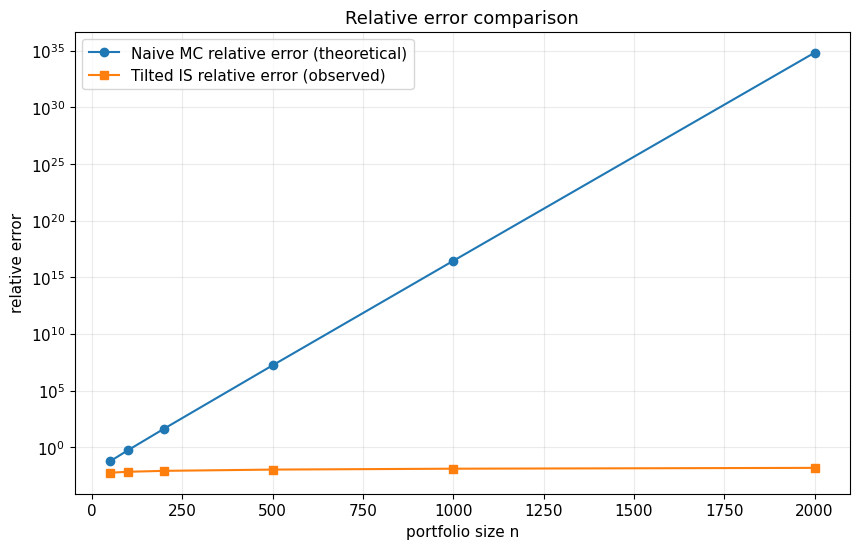

In [30]:
plt.figure()
plt.semilogy(
    mc_table["n"],
    mc_table["naive_relative_error_theoretical"],
    marker="o",
    label="Naive MC relative error (theoretical)",
)
plt.semilogy(
    mc_table["n"],
    mc_table["tilted_relative_error"],
    marker="s",
    label="Tilted IS relative error (observed)",
)
plt.xlabel("portfolio size n")
plt.ylabel("relative error")
plt.title("Relative error comparison")
plt.legend()
plt.show()

In [ ]:
plt.figure()
plt.semilogy(
    mc_table["n"],
    mc_table["variance_reduction_vs_naive"],
    marker="o",
)
plt.xlabel("portfolio size n")
plt.ylabel("estimated variance reduction factor")
plt.title("Variance reduction from exponential tilting")
plt.show()

The variance reduction factor compares the theoretical naive Monte Carlo variance to the observed tilted estimator variance.

For large $n$, the factor becomes enormous because naive simulation is trying to observe an event that almost never occurs.

## 7. Likelihood-ratio anatomy

The estimator is unbiased because each tilted sample is corrected by the inverse likelihood ratio:

$$
\exp(-\theta S_n+n\Gamma(\theta)).
$$

For a fixed $n$, the log-weight is linear in $S_n$:

$$
\log w(S_n)=-\theta S_n+n\Gamma(\theta).
$$

Larger numbers of defaults are more likely under the tilted law, but they receive smaller weights when translated back to the original law.

In [31]:
n_weight_demo = 500
k_weight_demo = binomial_tail_threshold(n=n_weight_demo, q=q)

rng = np.random.default_rng(BASE_SEED + 99)
tilted_counts = rng.binomial(n=n_weight_demo, p=tilted_p, size=20_000)
log_weights = log_likelihood_ratio_sum(
    theta=theta_q,
    sums=tilted_counts,
    n=n_weight_demo,
    gamma_theta=gamma_theta_q,
)

weight_demo = pd.DataFrame(
    {
        "default_count": tilted_counts,
        "default_rate": tilted_counts / n_weight_demo,
        "is_tail_event": tilted_counts >= k_weight_demo,
        "log_likelihood_weight": log_weights,
    }
)

display(
    weight_demo.groupby("is_tail_event")
    .agg(
        sample_count=("default_count", "size"),
        mean_default_rate=("default_rate", "mean"),
        mean_log_weight=("log_likelihood_weight", "mean"),
        min_log_weight=("log_likelihood_weight", "min"),
        max_log_weight=("log_likelihood_weight", "max"),
    )
    .style.format(
        {
            "mean_default_rate": "{:.3%}",
            "mean_log_weight": "{:.3f}",
            "min_log_weight": "{:.3f}",
            "max_log_weight": "{:.3f}",
        }
    )
)

,sample_count,mean_default_rate,mean_log_weight,min_log_weight,max_log_weight
is_tail_event,,,,,
False,9556,8.881%,-32.669,-40.456,-1.481
True,10444,11.028%,-50.863,-87.905,-42.151


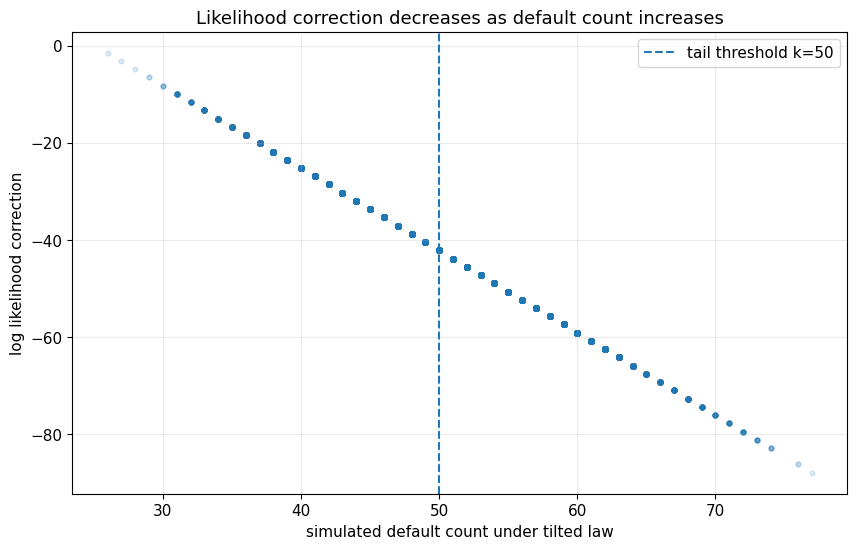

In [32]:
plt.figure()
plt.scatter(
    weight_demo["default_count"],
    weight_demo["log_likelihood_weight"],
    alpha=0.15,
    s=12,
)
plt.axvline(k_weight_demo, linestyle="--", label=f"tail threshold k={k_weight_demo}")
plt.xlabel("simulated default count under tilted law")
plt.ylabel("log likelihood correction")
plt.title("Likelihood correction decreases as default count increases")
plt.legend()
plt.show()

## 8. Quant scorecard

This table summarizes the core message in risk-engineering terms.

In [33]:
scorecard = mc_table[
    [
        "n",
        "exact_probability",
        "expected_naive_hits",
        "observed_naive_hits",
        "tilted_event_probability",
        "tilted_relative_error",
        "variance_reduction_vs_naive",
    ]
].copy()

display(
    scorecard.style.format(
        {
            "exact_probability": "{:.3e}",
            "expected_naive_hits": "{:.3e}",
            "tilted_event_probability": "{:.3f}",
            "tilted_relative_error": "{:.3%}",
            "variance_reduction_vs_naive": "{:.3e}",
        }
    )
)

,n,exact_probability,expected_naive_hits,observed_naive_hits,tilted_event_probability,tilted_relative_error,variance_reduction_vs_naive
0,50,3.210e-03,3.210e+02,357,0.569,0.550%,1.029e+02
1,100,3.442e-05,3.442e+00,2,0.549,0.667%,6.513e+03
2,200,5.391e-09,5.391e-04,0,0.534,0.806%,2.815e+07
3,500,3.577e-20,3.577e-15,0,0.522,1.040%,2.641e+18
4,1000,1.255e-38,1.255e-33,0,0.515,1.247%,5.220e+36
5,2000,2.173e-75,2.173e-70,0,0.511,1.475%,2.023e+73


## 9. Conclusion

The lesson is simple:

```text
Naive Monte Carlo estimates a rare probability by waiting for rare hits.
Importance sampling changes the simulation law so the rare event becomes common.
The likelihood ratio corrects the bias.
```

For the Bernoulli/binomial tail:

$$
\theta_q
=
\log\left(\frac{q(1-p)}{p(1-q)}\right),
$$

and under this tilt,

$$
p_\theta=q.
$$

So the simulation is centered exactly at the rare default rate.

This is the small, clean prototype for the later credit-risk problem:

```text
independent default portfolio
-> dependent Gaussian-copula portfolio
-> two-step importance sampling
-> extreme loss asymptotics
```

The next natural extension is to add a theory note or notebook section on **second-moment diagnostics**:

$$
M_2(\theta)
=
\mathbb E_\theta
\left[
1_{\{S_n/n\ge q\}}
\exp(-2\theta S_n+2n\Gamma(\theta))
\right],
$$

because asymptotic optimality is a statement about the exponential decay rate of this second moment.

## Reference

H. Pham, *Large Deviations in Mathematical Finance* (2010).

Relevant parts:

- Section 2.1: exponential change of probability measure.
- Section 2.2: Cramer's theorem.
- Remark 2.3: relation with importance sampling.
- Section 6.1.2: independent obligors in portfolio credit risk.